In [ ]:
# =============================================================================
#  NOTEBOOK 1 — TRAIN AND SAVE
#  Run this ONCE on your historical data.
#  At the end it downloads 3 pickle files to your computer:
#    lstm_model.pkl  |  scaler.pkl  |  meta.pkl
#
#  INPUT FILE:
#    Master_Historical Load_All_21_.csv
#
#  OUTPUTS:
#    Train_Evaluation/
#      training_history.png
#      All_Loads_Evaluation.png
#      Load_Forecast_Plots/   ← 21 individual PNGs (dpi=300)
#      Load_Forecasts_All.zip
#    saved_model/
#      lstm_model.pkl   ← download and keep these 3 files
#      scaler.pkl
#      meta.pkl
#    saved_model.zip    ← auto-downloaded at the end
# =============================================================================


# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Upload historical CSV
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files as colab_files
import shutil, os

print("Select your file:  Master_Historical Load_All_21_.csv")
uploaded = colab_files.upload()
print("Uploaded:", list(uploaded.keys()))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Imports
# ─────────────────────────────────────────────────────────────────────────────
import os, pickle, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from google.colab import files as colab_files

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
print('TensorFlow:', tf.__version__)




Select your file:  Master_Historical Load_All_21_.csv


Saving Master_Historical Load_All_21_.csv to Master_Historical Load_All_21_.csv
Uploaded: ['Master_Historical Load_All_21_.csv']
TensorFlow: 2.20.0


Config ready.
Data loaded: 2024-01-01 00:00:00  →  2024-12-10 23:45:00
Rows: 33120   Loads: 21

Training rows : 26496  (2024-01-01 00:00:00 → 2024-10-02 23:45:00)
Testing  rows : 6624  (2024-10-03 00:00:00 → 2024-12-10 23:45:00)
Scaler fitted on training rows only.
  train min sample: 0.0   max: 1.0
Sequences built — train: 26343, test: 6586
X shape: (26343, 96, 21)   y shape: (26343, 2016)


Model: "LoadForecast_96to96"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 100)        │        48,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2016)           │       203,616 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,816 (1.27 MB)

 Trainable params: 332,816 (1.27 MB)

 Non-trainable params: 0 (0.00 B)


Training model... please wait.
Epoch 1/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 115s 150ms/step - loss: 0.0112 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 2/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 105s 142ms/step - loss: 0.0080 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 3/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 104s 140ms/step - loss: 0.0072 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 4/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 107s 144ms/step - loss: 0.0067 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 5/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 109s 147ms/step - loss: 0.0063 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 6/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 141s 145ms/step - loss: 0.0061 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 7/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 104s 141ms/step - loss: 0.0059 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 8/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 107s 144ms/step - loss: 0.0058 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 9/20
741/741 ━━━━━━━━━━━━━━━━━━━━ 104s 141ms/step 

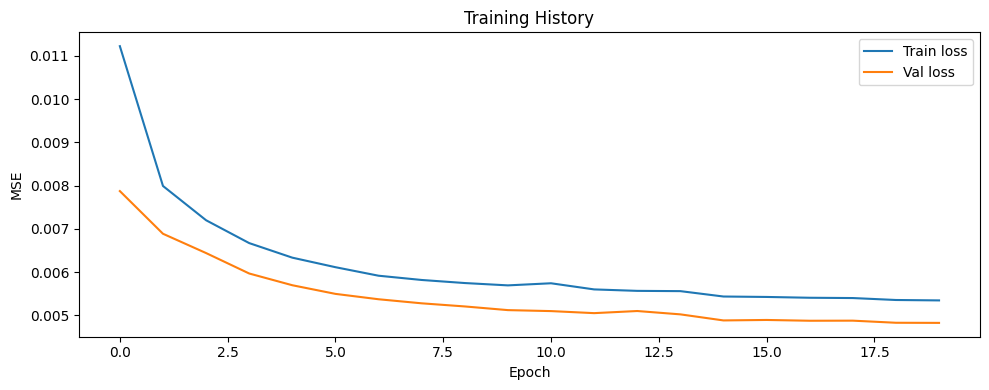

Training complete.

Load           | MSE        | RMSE       | R²        
----------------------------------------------------
LOAD1          | 0.2224     | 0.4716     | 0.6183    
LOAD2          | 2.6579     | 1.6303     | 0.9053    
LOAD3          | 0.0119     | 0.1093     | 0.2290    
LOAD4          | 0.0048     | 0.0694     | 0.2070    
LOAD5          | 0.6509     | 0.8068     | 0.9093    
LOAD6          | 0.0025     | 0.0497     | 0.2076    
LOAD7          | 0.3775     | 0.6144     | 0.9149    
LOAD8          | 0.2216     | 0.4707     | 0.8617    
LOAD9          | 0.0296     | 0.1720     | 0.2135    
LOAD10         | 0.0325     | 0.1802     | 0.1403    
LOAD11         | 0.0520     | 0.2281     | 0.2974    
LOAD12         | 0.4539     | 0.6737     | 0.6183    
LOAD13         | 0.0730     | 0.2701     | 0.8199    
LOAD14         | 0.1118     | 0.3343     | 0.3933    
LOAD15         | 0.2225     | 0.4717     | 0.6183    
LOAD16         | 0.0669     | 0.2587     | 0.2361    
LOAD17   

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Configuration
# ─────────────────────────────────────────────────────────────────────────────

HIST_CSV       = 'Master_Historical Load_All_21_.csv'
MODEL_DIR      = 'saved_model'
TRAIN_EVAL_DIR = 'Train_Evaluation'

LOOK_BACK      = 96    # 24 h input window  (96 × 15 min)
FORECAST_STEPS = 96    # 24 h output horizon
TRAIN_RATIO    = 0.8
EPOCHS         = 20
BATCH_SIZE     = 32

os.makedirs(MODEL_DIR,      exist_ok=True)
os.makedirs(TRAIN_EVAL_DIR, exist_ok=True)
print('Config ready.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Load and split data
# ─────────────────────────────────────────────────────────────────────────────

df        = pd.read_csv(HIST_CSV, index_col='Timestamp', parse_dates=True)
df        = df.sort_index().dropna()
load_cols = df.columns.tolist()
n_feat    = len(load_cols)
dataset   = df.values
n_rows    = len(dataset)

print(f'Data loaded: {df.index[0]}  →  {df.index[-1]}')
print(f'Rows: {n_rows}   Loads: {n_feat}')

# Split on raw data FIRST — then fit scaler only on training rows
n_train   = int(n_rows * TRAIN_RATIO)
train_raw = dataset[:n_train]
test_raw  = dataset[n_train:]

print(f'\nTraining rows : {n_train}  ({df.index[0]} → {df.index[n_train-1]})')
print(f'Testing  rows : {n_rows - n_train}  ({df.index[n_train]} → {df.index[-1]})')

# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Scale  (fit on training rows ONLY — no data leakage)
# ─────────────────────────────────────────────────────────────────────────────

scaler   = MinMaxScaler(feature_range=(0, 1))
train_sc = scaler.fit_transform(train_raw)   # learns min/max from train only
test_sc  = scaler.transform(test_raw)        # applies those same stats to test
all_sc   = np.vstack([train_sc, test_sc])

print('Scaler fitted on training rows only.')
print('  train min sample:', train_sc.min().round(4),
      '  max:', train_sc.max().round(4))


# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Build 96-step sequences
# ─────────────────────────────────────────────────────────────────────────────

X, y = [], []
for i in range(LOOK_BACK, len(all_sc) - FORECAST_STEPS + 1):
    X.append(all_sc[i - LOOK_BACK : i])
    y.append(all_sc[i : i + FORECAST_STEPS])

X, y   = np.array(X), np.array(y)
y_flat = y.reshape(len(y), -1)   # (N, 96*21) — flat output for Dense layer

sp               = int(TRAIN_RATIO * len(X))
X_train, X_test  = X[:sp],      X[sp:]
y_train, y_test  = y_flat[:sp], y_flat[sp:]
y_test_3d        = y[sp:]        # keep 3D for inverse-transform evaluation

print(f'Sequences built — train: {len(X_train)}, test: {len(X_test)}')
print(f'X shape: {X_train.shape}   y shape: {y_train.shape}')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Build LSTM model
# ─────────────────────────────────────────────────────────────────────────────

model = Sequential([
    LSTM(100, return_sequences=True,
         input_shape=(LOOK_BACK, n_feat)),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(FORECAST_STEPS * n_feat),   # predicts all 96 steps × 21 loads at once
], name='LoadForecast_96to96')

model.compile(optimizer='adam', loss='mse')
model.summary()


# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Train
# ─────────────────────────────────────────────────────────────────────────────

print('\nTraining model... please wait.')
history = model.fit(
    X_train, y_train,
    epochs           = EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.1,
    verbose          = 1,
    callbacks        = [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6, verbose=1),
    ]
)

# Training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Training History'); plt.legend(); plt.tight_layout()
plt.savefig(f'{TRAIN_EVAL_DIR}/training_history.png', dpi=150)
plt.show()
print('Training complete.')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Evaluate on test set
# ─────────────────────────────────────────────────────────────────────────────

y_pred_flat = model.predict(X_test, verbose=0)
y_pred_3d   = y_pred_flat.reshape(-1, FORECAST_STEPS, n_feat)

# Inverse transform back to kW
y_pred_kw = scaler.inverse_transform(
    y_pred_3d.reshape(-1, n_feat)).reshape(-1, FORECAST_STEPS, n_feat)
y_true_kw = scaler.inverse_transform(
    y_test_3d.reshape(-1, n_feat)).reshape(-1, FORECAST_STEPS, n_feat)

yp = y_pred_kw.reshape(-1, n_feat)   # flatten time axis for per-load metrics
yt = y_true_kw.reshape(-1, n_feat)

# Console table
print(f"\n{'Load':<14} | {'MSE':<10} | {'RMSE':<10} | {'R²':<10}")
print('-' * 52)
for i, col in enumerate(load_cols):
    mse  = mean_squared_error(yt[:, i], yp[:, i])
    rmse = np.sqrt(mse)
    r2   = r2_score(yt[:, i], yp[:, i])
    print(f'{col:<14} | {mse:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}')




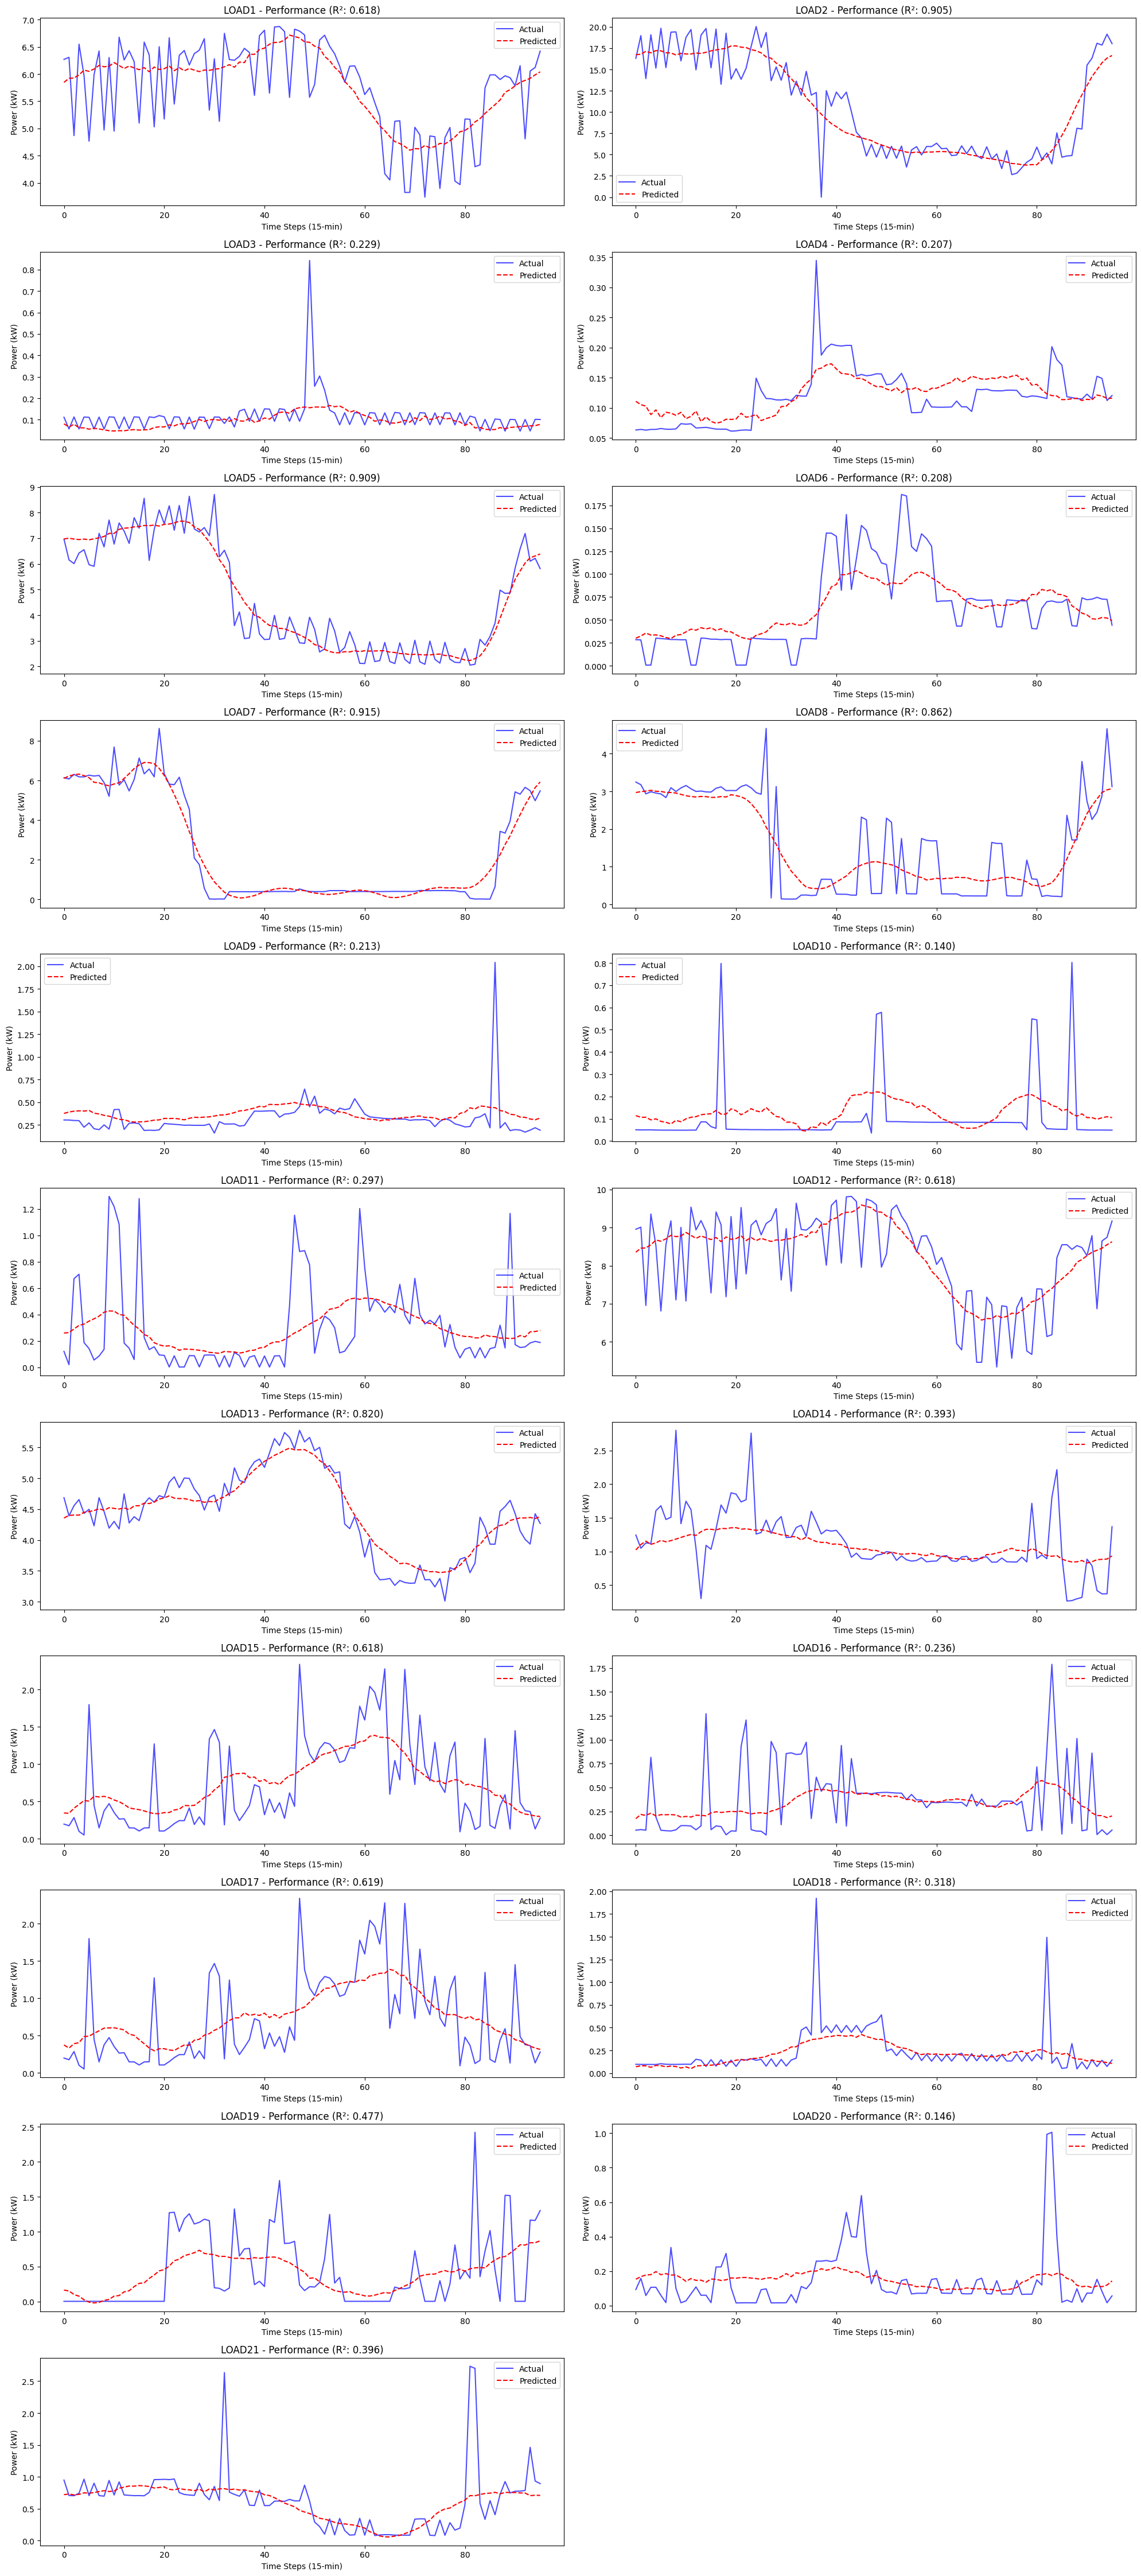

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Combined 21-load subplot  (your original plt.subplot(11,2,...) style)
# ─────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(20, 45))
for i, col in enumerate(load_cols):
    r2 = r2_score(yt[:, i], yp[:, i])
    plt.subplot(11, 2, i + 1)
    plt.plot(yt[:96, i], label='Actual',    color='blue', alpha=0.7)
    plt.plot(yp[:96, i], label='Predicted', color='red',  linestyle='--')
    plt.title(f'{col} - Performance (R²: {r2:.3f})')
    plt.xlabel('Time Steps (15-min)')
    plt.ylabel('Power (kW)')
    plt.legend()
plt.tight_layout()
plt.savefig(f'{TRAIN_EVAL_DIR}/All_Loads_Evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()




In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 — Individual PNGs  (your original Load_Forecast_Plots/ style)
# ─────────────────────────────────────────────────────────────────────────────

eval_plots = os.path.join(TRAIN_EVAL_DIR, 'Load_Forecast_Plots')
os.makedirs(eval_plots, exist_ok=True)
print(f"Saving individual evaluation plots to '{eval_plots}'...")

for i, col in enumerate(load_cols):
    plt.figure(figsize=(10, 5))
    r2 = r2_score(yt[:, i], yp[:, i])
    plt.plot(yt[:96, i], label='Actual',    color='blue', alpha=0.7)
    plt.plot(yp[:96, i], label='Predicted', color='red',  linestyle='--')
    plt.title(f'Forecast Performance: {col} (R²: {r2:.3f})', fontsize=16 , fontweight='bold')
    plt.xlabel('Time Steps (15-min)', fontsize=14 , fontweight='bold')
    plt.ylabel('Power (kW)', fontsize=14 , fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig(os.path.join(eval_plots,
                f"{col.replace(' ', '_')}_forecast.png"),
                dpi=300, bbox_inches='tight')
    plt.close()

print('All individual evaluation images saved.')

# ZIP evaluation plots
shutil.make_archive(
    os.path.join(TRAIN_EVAL_DIR, 'Load_Forecasts_All'), 'zip', eval_plots)
print(f'Evaluation ZIP  →  {TRAIN_EVAL_DIR}/Load_Forecasts_All.zip')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 — Save model + scaler + metadata to pickle files
# ─────────────────────────────────────────────────────────────────────────────

# Pickle 1: model weights + architecture
with open(f'{MODEL_DIR}/lstm_model.pkl', 'wb') as f:
    pickle.dump({
        'weights'       : model.get_weights(),
        'model_config'  : model.get_config(),
        'look_back'     : LOOK_BACK,
        'forecast_steps': FORECAST_STEPS,
        'n_features'    : n_feat,
    }, f)

# Pickle 2: scaler (fitted on training data only)
with open(f'{MODEL_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Pickle 3: column names — ensures forecast columns match training columns
with open(f'{MODEL_DIR}/meta.pkl', 'wb') as f:
    pickle.dump({'load_cols': load_cols}, f)

print(f'\nPickle files saved to  {MODEL_DIR}/')
print('  lstm_model.pkl  — model weights + architecture')
print('  scaler.pkl      — MinMaxScaler fitted on training data')
print('  meta.pkl        — column names and hyperparameters')


# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 — Download all 3 pickle files as a single ZIP
#
#  IMPORTANT: Save saved_model.zip to your computer.
#  You will upload it in Notebook 2 every day to make forecasts.
# ─────────────────────────────────────────────────────────────────────────────

shutil.make_archive('saved_model', 'zip', MODEL_DIR)
print('Downloading  saved_model.zip  (contains lstm_model.pkl, scaler.pkl, meta.pkl)...')
colab_files.download('saved_model.zip')
print('\nDone. Keep saved_model.zip safe — it is your trained model.')
print('You will upload it in Notebook 2 each time you want to forecast.')

Saving individual evaluation plots to 'Train_Evaluation/Load_Forecast_Plots'...
All individual evaluation images saved.
Evaluation ZIP  →  Train_Evaluation/Load_Forecasts_All.zip

Pickle files saved to  saved_model/
  lstm_model.pkl  — model weights + architecture
  scaler.pkl      — MinMaxScaler fitted on training data
  meta.pkl        — column names and hyperparameters


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done. Keep saved_model.zip safe — it is your trained model.
You will upload it in Notebook 2 each time you want to forecast.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ADDITIONAL — Download individual load graphs as a ZIP
# Paste this immediately after the "Evaluation ZIP" line in CELL 11
# ─────────────────────────────────────────────────────────────────────────────

individual_zip_name = 'Individual_Load_Graphs'
shutil.make_archive(individual_zip_name, 'zip', eval_plots)

print(f'Individual load graphs ZIP  →  {individual_zip_name}.zip')
print(f'Contains {len([f for f in os.listdir(eval_plots) if f.endswith(".png")])} PNG files:')
for fn in sorted(os.listdir(eval_plots)):
    if fn.endswith('.png'):
        size = os.path.getsize(os.path.join(eval_plots, fn))
        print(f'  {fn}  ({size:,} bytes)')

colab_files.download(f'{individual_zip_name}.zip')
print('Download started.')

Individual load graphs ZIP  →  Individual_Load_Graphs.zip
Contains 21 PNG files:
  LOAD10_forecast.png  (199,309 bytes)
  LOAD11_forecast.png  (246,350 bytes)
  LOAD12_forecast.png  (263,283 bytes)
  LOAD13_forecast.png  (225,485 bytes)
  LOAD14_forecast.png  (210,242 bytes)
  LOAD15_forecast.png  (254,960 bytes)
  LOAD16_forecast.png  (240,252 bytes)
  LOAD17_forecast.png  (254,350 bytes)
  LOAD18_forecast.png  (208,416 bytes)
  LOAD19_forecast.png  (216,590 bytes)
  LOAD1_forecast.png  (271,203 bytes)
  LOAD20_forecast.png  (207,537 bytes)
  LOAD21_forecast.png  (206,300 bytes)
  LOAD2_forecast.png  (245,651 bytes)
  LOAD3_forecast.png  (205,288 bytes)
  LOAD4_forecast.png  (201,097 bytes)
  LOAD5_forecast.png  (233,827 bytes)
  LOAD6_forecast.png  (228,169 bytes)
  LOAD7_forecast.png  (183,269 bytes)
  LOAD8_forecast.png  (212,143 bytes)
  LOAD9_forecast.png  (188,477 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
